In [17]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

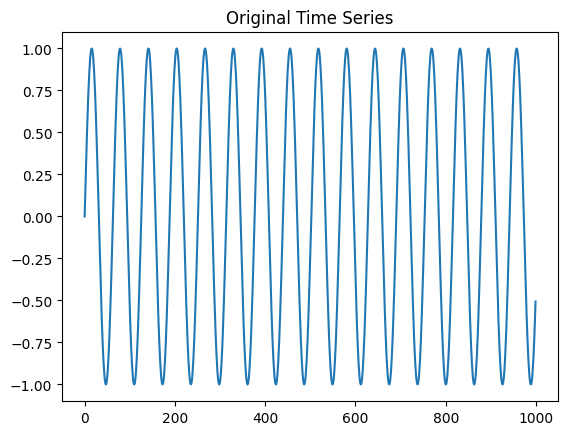

In [18]:
# Generate sine wave data
time_steps = np.linspace(0, 100, 1000)
data = np.sin(time_steps)

# Plot data
plt.plot(data)
plt.title("Original Time Series")
plt.show()

In [19]:
def create_sequences(data, seq_length):
    sequences = []
    labels = []

    for i in range(len(data) - seq_length):
        seq = data[i:i+seq_length]
        label = data[i+seq_length]
        sequences.append(seq)
        labels.append(label)

    return np.array(sequences), np.array(labels)

seq_length = 20
X, y = create_sequences(data, seq_length)

# Convert to tensors
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
y = torch.tensor(y, dtype=torch.float32)

In [20]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [21]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(RNNModel, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)   # out: (batch, seq_len, hidden)
        out = out[:, -1, :]    # take last time step
        out = self.fc(out)
        return out

In [22]:
model = RNNModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [23]:
epochs = 40
train_losses = []

for epoch in range(epochs):
    model.train()

    output = model(X_train)
    loss = criterion(output.squeeze(), y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    if epoch%5 == 0 :
     print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

Epoch [1/40], Loss: 0.439948
Epoch [6/40], Loss: 0.360510
Epoch [11/40], Loss: 0.277531
Epoch [16/40], Loss: 0.183826
Epoch [21/40], Loss: 0.097799
Epoch [26/40], Loss: 0.082736
Epoch [31/40], Loss: 0.055853
Epoch [36/40], Loss: 0.036909


In [24]:
model.eval()
with torch.no_grad():
    predictions = model(X_test).squeeze().numpy()
    actual = y_test.numpy()

In [25]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")

MSE: 0.029779
RMSE: 0.172566


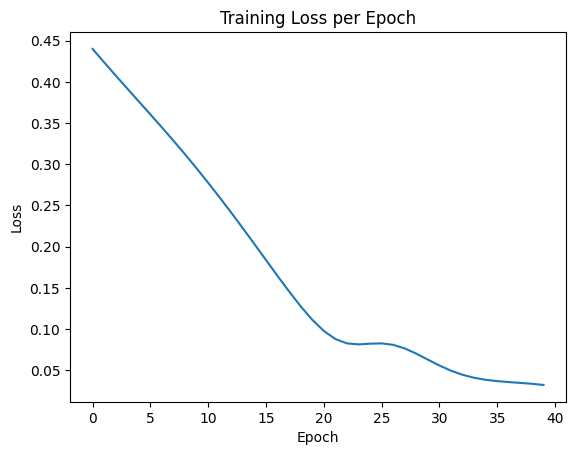

In [26]:
plt.plot(train_losses)
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

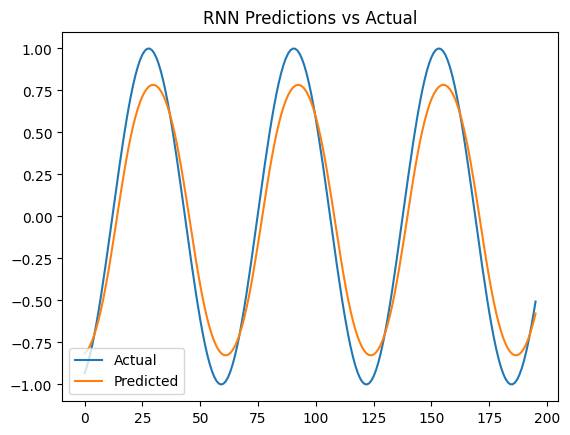

In [27]:
plt.plot(actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("RNN Predictions vs Actual")
plt.show()